# EDA y MCO para propension de consumo

Este notebook llama funciones de `src/` para que aqui solo queden comentarios, interpretacion y resultados.

In [2]:
from pathlib import Path
import os
import sys

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

os.environ.setdefault('MPLCONFIGDIR', str(project_root / '.matplotlib-cache'))

from cannabis_tax.analysis import build_propensity_dataset
from cannabis_tax.analysis import categorical_summary
from cannabis_tax.analysis import coefficient_table
from cannabis_tax.analysis import fit_lpm
from cannabis_tax.analysis import fit_probit
from cannabis_tax.analysis import missing_summary
from cannabis_tax.analysis import numeric_summary
from cannabis_tax.analysis import plot_histograms
from cannabis_tax.analysis import plot_target_rate_by_category
from cannabis_tax.analysis import prepare_propensity_regression_data

import matplotlib.pyplot as plt

plt.style.use('ggplot')

Matplotlib is building the font cache; this may take a moment.


## 1. Construir base final de trabajo

In [3]:
df = build_propensity_dataset()
df.head()

,directorio,secuencia_encuesta,secuencia_p,orden,propension_12m,consumo_12m,consumo_12m_missing_original,precio_compra,log_precio_compra,cantidad_consumo,...,actitud_legalizacion,actitud_regulacion,actitud_prevencion,actitud_sanciones,actitud_tratamiento,d2_01,d2_03,d2_04,d2_06,d2_07
0,7,1,1,1,1,1.0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5,2,1,1.0,1.0
1,38,3,1,3,0,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,5,6,0,1.0,1.0
2,48,1,1,1,0,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9,6,0,1.0,1.0
3,99,5,1,5,0,NaN,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9,5,1,1.0,2.0
4,129,1,1,1,1,1.0,0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,9,3,2,1.0,1.0


## 2. Revision rapida de faltantes y descriptivos

In [5]:
missing_summary(
    df,
    [
        'propension_12m',
        'precio_compra',
        'cantidad_consumo',
        'sexo_label',
        'edad',
        'educacion_label',
    ],
)

,variable,non_null,missing,missing_pct
0,precio_compra,756,3226,0.810146
1,cantidad_consumo,1188,2794,0.701657
2,edad,3982,0,0.000000
3,educacion_label,3982,0,0.000000
4,propension_12m,3982,0,0.000000
5,sexo_label,3982,0,0.000000


In [6]:
numeric_summary(df, ['edad', 'precio_compra', 'cantidad_consumo', 'gasto_valor'])

,count,mean,std,min,25%,50%,75%,max
edad,3982.0,33.836514,13.139204,12.0,24.0,30.0,42.0,65.0
precio_compra,756.0,43019.841270,55502.552920,1000.0,10000.0,20000.0,50000.0,400000.0
cantidad_consumo,1188.0,16.664141,26.558498,1.0,1.0,4.0,20.0,150.0
gasto_valor,1014.0,3044.970414,2280.634242,500.0,2000.0,2000.0,3500.0,20000.0


In [7]:
categorical_summary(df, ['sexo_label', 'educacion_label', 'frecuencia_consumo'])

,variable,category,count
0,sexo_label,Hombre,2708
1,sexo_label,Mujer,1274
2,educacion_label,Media,1187
3,educacion_label,Universitaria,865
4,educacion_label,Tecnica/tecnologica,692
5,educacion_label,Basica secundaria,564
6,educacion_label,Basica primaria,407
7,educacion_label,Postgrado,230
8,educacion_label,Ninguno,29
9,educacion_label,Preescolar,6


## 3. Graficos EDA

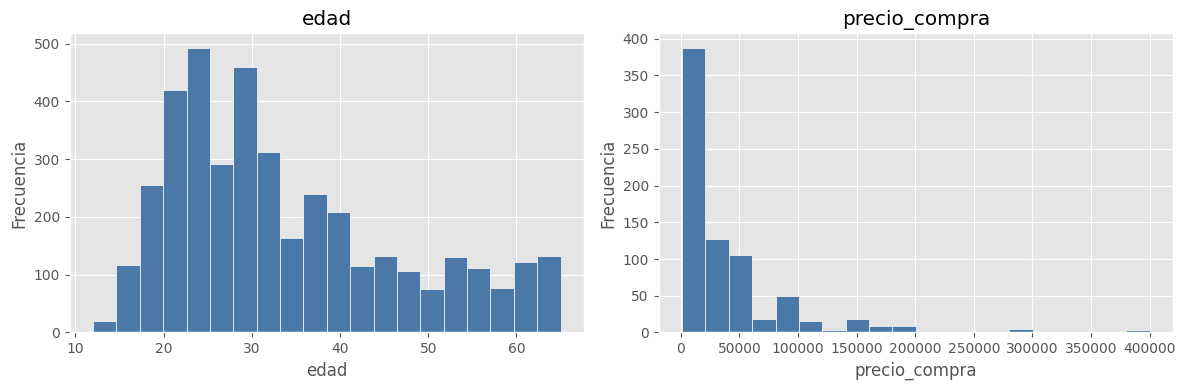

In [8]:
plot_histograms(df, ['edad', 'precio_compra'])
plt.show()

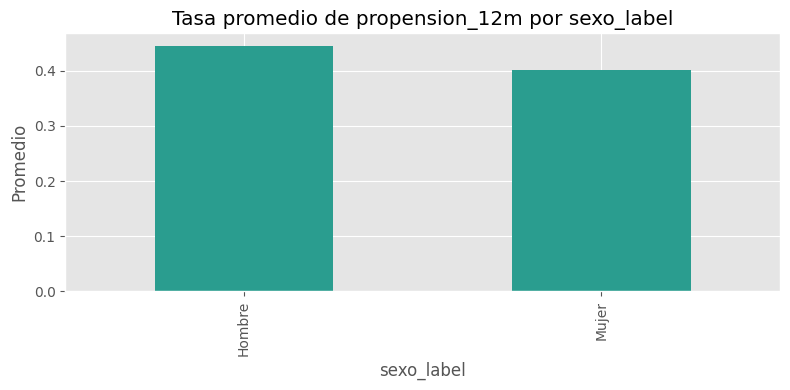

In [9]:
plot_target_rate_by_category(df, 'propension_12m', 'sexo_label')
plt.show()

## 4. MCO benchmark

In [10]:
reg_df = prepare_propensity_regression_data(df, require_price=True)
reg_df.head()

,propension_12m,edad,edad_cuadrado,sexo_label,educacion_grupo,log_precio_compra
7,1.0,20,400,Hombre,Superior,9.210340
13,0.0,21,441,Hombre,Superior,9.104980
20,1.0,28,784,Hombre,Media,12.611538
24,1.0,23,529,Mujer,Media,9.740969
25,0.0,50,2500,Mujer,Media,11.695247


In [11]:
lpm_result = fit_lpm(reg_df)
coefficient_table(lpm_result)

,coef,std_err,z_or_t,p_value
C(educacion_grupo)[T.Media],0.105448,0.054715,1.927207,0.053954
C(educacion_grupo)[T.Superior],0.079122,0.057082,1.386109,0.165714
C(sexo_label)[T.Mujer],0.006194,0.040513,0.152884,0.878490
Intercept,0.102076,0.178735,0.571104,0.567929
edad,0.012734,0.008491,1.499628,0.133711
edad_cuadrado,-0.000271,0.000118,-2.293587,0.021814
log_precio_compra,0.044311,0.011801,3.755031,0.000173


In [12]:
print(lpm_result.summary())

                            OLS Regression Results                            
Dep. Variable:         propension_12m   R-squared:                       0.061
Model:                            OLS   Adj. R-squared:                  0.053
Method:                 Least Squares   F-statistic:                     7.762
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           4.08e-08
Time:                        18:21:31   Log-Likelihood:                -426.40
No. Observations:                 755   AIC:                             866.8
Df Residuals:                     748   BIC:                             899.2
Df Model:                           6                                         
Covariance Type:                  HC1                                         
                                     coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

## 5. Probit

Deja esta parte para la siguiente etapa o ejecútala cuando termines de revisar el MCO.

In [13]:
probit_result = fit_probit(reg_df)
coefficient_table(probit_result)

,coef,std_err,z_or_t,p_value
C(educacion_grupo)[T.Media],0.321542,0.160695,2.000952,0.045398
C(educacion_grupo)[T.Superior],0.242270,0.166441,1.455595,0.145505
C(sexo_label)[T.Mujer],0.012086,0.128090,0.094359,0.924824
Intercept,-1.261720,0.564440,-2.235347,0.025395
edad,0.031028,0.025823,1.201535,0.229544
edad_cuadrado,-0.000700,0.000351,-1.995408,0.045998
log_precio_compra,0.144431,0.039052,3.698424,0.000217
